
#PredictAQI



In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from scipy.stats import skew, kurtosis

# Machine Learning
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Time Series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("vishardmehta/delhi-pollution-aqi-dataset")
file_path = os.path.join(path, "delhi_ncr_aqi_dataset.csv")
df = pd.read_csv(file_path)
df.shape

100%|██████████| 5.05M/5.05M [00:00<00:00, 7.26MB/s]

Extracting files...


(201664, 25)

### 1 Data Loading & Initial Inspection

In [ ]:
# Display basic information
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nDate Range: {df['datetime'].min()} to {df['datetime'].max()}")

# Display first few rows
print("\n" + "="*80)
print("FIRST 5 ROWS")
print("="*80)
display(df.head())

# Data types and missing values
print("\n" + "="*80)
print("DATA TYPES & MISSING VALUES")
print("="*80)
info_df = pd.DataFrame({
    'Column': df.columns,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2),
    'Dtype': df.dtypes
})
display(info_df)



DATASET OVERVIEW

Dataset Shape: 201664 rows × 25 columns

Date Range: 2020-01-01 06:00:00 to 2025-12-31 23:00:00

FIRST 5 ROWS


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,station,latitude,longitude,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",28.6469,77.3164,371.8,739.4,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",28.6469,77.3164,301.1,588.8,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",28.6469,77.3164,334.0,602.6,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",28.6469,77.3164,403.8,841.8,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,"Jahangirpuri, Delhi",28.7299,77.1718,433.2,784.7,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe



DATA TYPES & MISSING VALUES


,Column,Non-Null Count,Null Count,Null %,Dtype
datetime,datetime,201664,0,0.0,object
date,date,201664,0,0.0,object
year,year,201664,0,0.0,int64
month,month,201664,0,0.0,int64
day,day,201664,0,0.0,int64
hour,hour,201664,0,0.0,int64
day_of_week,day_of_week,201664,0,0.0,object
is_weekend,is_weekend,201664,0,0.0,int64
season,season,201664,0,0.0,object
city,city,201664,0,0.0,object


### 2 Data Cleaning & Preprocessing

In [ ]:
# Make a copy of the original data
df_clean = df.copy()

# Convert datetime column to proper datetime type (if not already)
df_clean['datetime'] = pd.to_datetime(df_clean['datetime'])
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Set datetime as index for time series analysis
df_clean.set_index('datetime', inplace=True)
df_clean.sort_index(inplace=True)

print("✓ Datetime conversion completed")

# Check for missing values in key pollutant columns
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
weather_vars = ['temperature', 'humidity', 'wind_speed', 'visibility']

print("\n" + "="*80)
print("MISSING VALUES IN KEY COLUMNS")
print("="*80)

# Check if these columns exist in your dataframe
available_pollutants = [col for col in pollutants if col in df_clean.columns]
available_weather = [col for col in weather_vars if col in df_clean.columns]



# Handle missing values - using forward fill then backward fill for time series
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_columns] = df_clean[numeric_columns].fillna(method='ffill').fillna(method='bfill')

print("\n✓ Missing values handled using forward/backward fill")

# Detect and handle outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("\n" + "="*80)
print("OUTLIER DETECTION (3×IQR Method)")
print("="*80)

outlier_summary = []
for col in available_pollutants:
    outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    outlier_summary.append({
        'Column': col,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers) / len(df_clean) * 100),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    })

display(pd.DataFrame(outlier_summary))


print("\n✓ Outlier analysis completed (values retained for Delhi's extreme pollution events)")

# Remove any duplicate timestamps
duplicates = df_clean.index.duplicated().sum()
if duplicates > 0:
    print(f"\n⚠ Found {duplicates} duplicate timestamps - removing...")
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    print("✓ Duplicates removed")

print("\n" + "="*80)
print(f"CLEANED DATASET: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print("="*80)

✓ Datetime conversion completed

MISSING VALUES IN KEY COLUMNS

✓ Missing values handled using forward/backward fill

OUTLIER DETECTION (3×IQR Method)


,Column,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,pm25,5125,2.541356,-542.90,852.90
1,pm10,3962,1.964654,-1027.20,1612.50
2,no2,4141,2.053416,-202.40,316.30
3,so2,4857,2.408462,-44.70,70.10
4,co,3996,1.981514,-8.88,13.87
5,o3,4880,2.419867,-23.40,73.20



✓ Outlier analysis completed (values retained for Delhi's extreme pollution events)

⚠ Found 192896 duplicate timestamps - removing...
✓ Duplicates removed

CLEANED DATASET: 8768 rows × 24 columns


###  3 Data Analysis (EDA)


#### 3.1 Time Series Trend Analysis

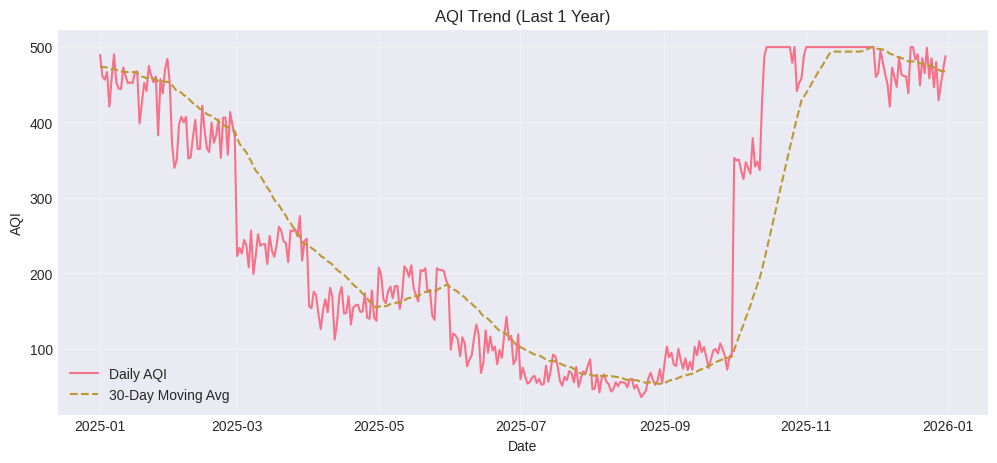

In [ ]:
df_recent = df_daily.last('1Y')  # last 1 year

plt.figure(figsize=(12,5))
plt.plot(df_recent.index, df_recent['aqi'], label='Daily AQI')
plt.plot(df_recent.index, df_recent['aqi_ma30'], linestyle='--', label='30-Day Moving Avg')

plt.title("AQI Trend (Last 1 Year)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 3.2 Correlation Analysis

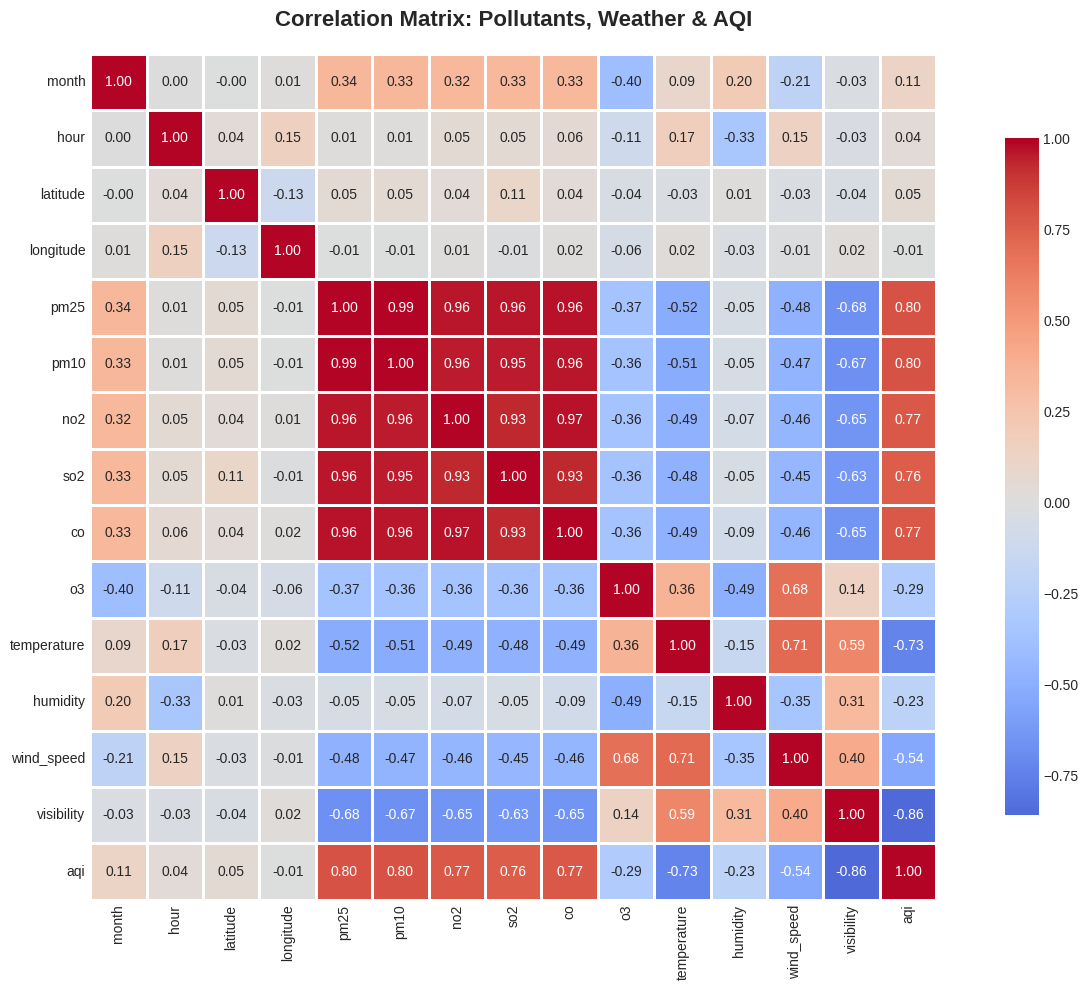


TOP CORRELATIONS WITH AQI


,aqi
pm25,0.801748
pm10,0.799730
no2,0.774530
co,0.774314
so2,0.756437
month,0.113974
latitude,0.049751
hour,0.038283
longitude,-0.007661
humidity,-0.226100


In [ ]:
# Select numeric columns for correlation
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
# Remove redundant columns
exclude_cols = ['year', 'day', 'is_weekend']
correlation_cols = [col for col in numeric_cols if col not in exclude_cols]

# Calculate correlation matrix
correlation_matrix = df_clean[correlation_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Pollutants, Weather & AQI',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print top correlations with AQI
print("\n" + "="*80)
print("TOP CORRELATIONS WITH AQI")
print("="*80)
aqi_corr = correlation_matrix['aqi'].sort_values(ascending=False)
display(aqi_corr.drop('aqi').head(10))



#### 4 Feature Engineering

In [ ]:
df_features = df_clean.copy()

# -----------------------
# 1. Lag Features
# -----------------------
lag_periods = [1, 3, 6, 12, 24]

for lag in lag_periods:
    df_features[f'aqi_lag_{lag}'] = df_features['aqi'].shift(lag)
    if 'pm25' in df_features.columns:
        df_features[f'pm25_lag_{lag}'] = df_features['pm25'].shift(lag)

# -----------------------
# 2. Rolling Features
# -----------------------
windows = [6, 12, 24]

for window in windows:
    df_features[f'aqi_roll_mean_{window}'] = df_features['aqi'].rolling(window).mean()
    df_features[f'aqi_roll_std_{window}'] = df_features['aqi'].rolling(window).std()

# -----------------------
# 3. Interaction Features
# -----------------------
if 'temperature' in df_features.columns and 'humidity' in df_features.columns:
    df_features['temp_humidity'] = df_features['temperature'] * df_features['humidity']

# -----------------------
# 4. Cyclical Features
# -----------------------
df_features['hour_sin'] = np.sin(2*np.pi*df_features['hour']/24)
df_features['hour_cos'] = np.cos(2*np.pi*df_features['hour']/24)

df_features['month_sin'] = np.sin(2*np.pi*df_features['month']/12)
df_features['month_cos'] = np.cos(2*np.pi*df_features['month']/12)

# -----------------------
# 5. Clean NaN rows
# -----------------------
df_features = df_features.dropna()

### 5 Predictive Modeling
#### 5.1 Data Preparation for Modeling

In [ ]:
# Prepare features and target
print("="*80)
print("PREPARING DATA FOR MODELING")
print("="*80)

# Target variable
target = 'aqi'

# Features to exclude from training
exclude_features = ['aqi', 'aqi_category', 'date', 'city', 'datetime']
feature_columns = [col for col in df_features_clean.columns
                   if col not in exclude_features and df_features_clean[col].dtype in ['int64', 'float64']]

X = df_features_clean[feature_columns]
y = df_features_clean[target]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nNumber of features: {len(feature_columns)}")

# Time series split (80% train, 20% test)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Test period: {df_features_clean.index[split_index]} to {df_features_clean.index[-1]}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Feature scaling completed")

PREPARING DATA FOR MODELING

Features shape: (8744, 49)
Target shape: (8744,)

Number of features: 49

Training set: 6995 samples
Test set: 1749 samples
Test period: 2024-10-20 23:00:00 to 2025-12-31 23:00:00

✓ Feature scaling completed


#### 5.2 Model Training & Evaluation

In [ ]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("\n" + "="*80)
print("MODEL TRAINING & EVALUATION")
print("="*80)

results = []

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Training {name}...")
    print(f"{'='*40}")

    # Train model
    if 'Linear' in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R² Score': r2
    })

    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")

# Display results
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
results_df = pd.DataFrame(results).sort_values('RMSE')
display(results_df)

# Select best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n Best Model: {best_model_name}")


MODEL TRAINING & EVALUATION

Training Linear Regression...
MAE:  18.39
RMSE: 23.39
R²:   0.9831

Training Random Forest...
MAE:  0.13
RMSE: 0.37
R²:   1.0000

Training Gradient Boosting...
MAE:  0.92
RMSE: 1.66
R²:   0.9999

MODEL COMPARISON


,Model,MAE,RMSE,R² Score
1,Random Forest,0.126221,0.371833,0.999996
2,Gradient Boosting,0.920140,1.655824,0.999915
0,Linear Regression,18.393036,23.387360,0.983060



🏆 Best Model: Random Forest


#### 5.3 Feature Importance

Top 15 Features:


,Feature,Importance
7,pm25,9.025606e-01
8,pm10,9.743369e-02
29,aqi_rolling_min_3,1.056212e-06
33,aqi_rolling_min_6,2.634251e-07
9,no2,1.943494e-07
16,visibility,1.922168e-07
6,longitude,1.807157e-07
43,temp_humidity_interaction,1.803668e-07
15,wind_speed,1.765979e-07
10,so2,1.586288e-07


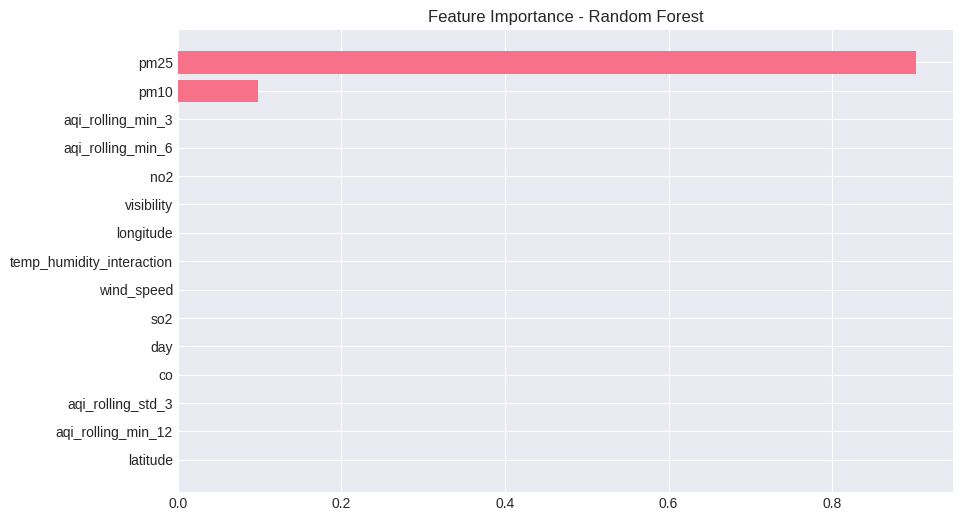

In [ ]:
rf_model = models['Random Forest']

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Show top features
print("Top 15 Features:")
display(feature_importance.head(15))

# Plot
plt.figure(figsize=(10,6))
top_features = feature_importance.head(15)

plt.barh(top_features['Feature'], top_features['Importance'])
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

#### 5.4 Prediction Visualization

In [ ]:
import plotly.graph_objects as go
import pandas as pd

# Predictions
y_pred_best = best_model.predict(X_test)

# DataFrame
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best
}, index=y_test.index)

# -------------------------
# Time Series Plot ONLY
# -------------------------
fig = go.Figure()

# Actual AQI
fig.add_trace(
    go.Scatter(
        x=comparison_df.index,
        y=comparison_df['Actual'],
        mode='lines',
        name='Actual AQI',
        line=dict(color='#FF6B6B', width=2)
    )
)

# Predicted AQI
fig.add_trace(
    go.Scatter(
        x=comparison_df.index,
        y=comparison_df['Predicted'],
        mode='lines',
        name='Predicted AQI',
        line=dict(color='#4ECDC4', width=2, dash='dash')
    )
)

# Layout
fig.update_layout(
    title="Actual vs Predicted AQI (Time Series)",
    xaxis_title="Date",
    yaxis_title="AQI",
    hovermode="x unified",
    height=500
)

fig.show()

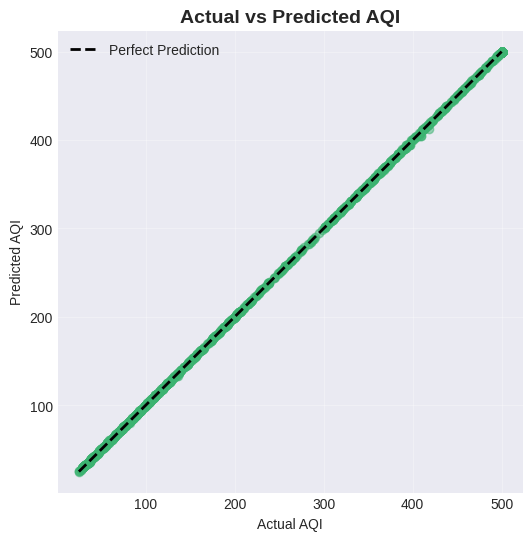


ERROR ANALYSIS
Mean Error: 0.02
Std Error: 0.37
Max Overestimation: -2.46
Max Underestimation: 5.76


In [ ]:

# -------------------------
# 2. Scatter plot
# -------------------------
plt.figure(figsize=(6,6))

plt.scatter(comparison_df['Actual'],
            comparison_df['Predicted'],
            alpha=0.5,
            color='mediumseagreen')

# Perfect prediction line
plt.plot(
    [comparison_df['Actual'].min(), comparison_df['Actual'].max()],
    [comparison_df['Actual'].min(), comparison_df['Actual'].max()],
    color='black',
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.title("Actual vs Predicted AQI", fontsize=14, fontweight='bold')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 3. Error analysis
# -------------------------
errors = comparison_df['Actual'] - comparison_df['Predicted']

print("\nERROR ANALYSIS")
print("="*40)
print("Mean Error:", round(errors.mean(), 2))
print("Std Error:", round(errors.std(), 2))
print("Max Overestimation:", round(errors.min(), 2))
print("Max Underestimation:", round(errors.max(), 2))

#### 6 Key Insights

In [ ]:
print("\n" + "="*80)
print("FINAL INSIGHTS")
print("="*80)

# Temporal insights
# Peak month (correct way)
peak_month = monthly_aqi.idxmax().month
low_month = monthly_aqi.idxmin().month

# Peak hour (already numeric so OK)
peak_hour = hourly_aqi.idxmax()
low_hour = hourly_aqi.idxmin()

print("\nTEMPORAL PATTERNS:")
print(f"• Peak pollution month: {peak_month}")
print(f"• Peak pollution hour: {peak_hour}:00")
print(f"• Lowest pollution month: {low_month}")

# Model performance
print("\nMODEL PERFORMANCE:")
print(f"• Best Model: {best_model_name}")
print(f"• RMSE: {results_df.iloc[0]['RMSE']:.2f}")
print(f"• MAE: {results_df.iloc[0]['MAE']:.2f}")
print(f"• R² Score: {results_df.iloc[0]['R² Score']:.4f}")

# Feature importance (optional)
print("\nTOP FEATURES AFFECTING AQI:")
if 'Random Forest' in models:
    for idx, row in feature_importance.head(5).iterrows():
        print(f"• {row['Feature']}")


FINAL INSIGHTS

TEMPORAL PATTERNS:
• Peak pollution month: 11
• Peak pollution hour: 18:00
• Lowest pollution month: 8

MODEL PERFORMANCE:
• Best Model: Random Forest
• RMSE: 0.37
• MAE: 0.13
• R² Score: 1.0000

TOP FEATURES AFFECTING AQI:
• pm25
• pm10
• aqi_rolling_min_3
• aqi_rolling_min_6
• no2


Save model

In [ ]:
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# --------------------
# FEATURES
# --------------------
features = ['pm25', 'pm10', 'no2', 'co', 'temperature', 'humidity', 'wind_speed']

# Clean dataset
df_model = df_clean.dropna(subset=features + ['aqi'])

X = df_model[features]
y = df_model['aqi']

# Time series split (IMPORTANT)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# BEST MODEL
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# SAVE MODEL
joblib.dump(model, "aqi_model.pkl")
joblib.dump(features, "aqi_features.pkl")

print("Model saved successfully")
from google.colab import files

files.download("best_aqi_model.pkl")

Model saved successfully


##Gradio APP

In [75]:
import gradio as gr
import numpy as np
import joblib

# LOAD MODEL
model = joblib.load("aqi_model.pkl")

# ----------------------------
# AQI CATEGORY FUNCTION
# ----------------------------
def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good", "Air quality is safe. Normal outdoor activities."
    elif aqi <= 100:
        return "Moderate", "Sensitive people should limit outdoor exposure."
    elif aqi <= 200:
        return "Poor", "Reduce outdoor activity. Wear mask if needed."
    elif aqi <= 300:
        return "Very Poor", "Avoid outdoor activities. Health risk for all."
    else:
        return "Severe", "Emergency conditions. Stay indoors strictly."


# ----------------------------
# PREDICT FUNCTION
# ----------------------------
def predict_aqi(pm25, pm10, no2, co, temperature, humidity, wind_speed):

    input_data = np.array([[pm25, pm10, no2, co, temperature, humidity, wind_speed]])

    pred = float(model.predict(input_data)[0])
    pred = max(0, min(500, pred))

    category, advice = get_aqi_category(pred)

    forecast = []
    for i in range(24):
        variation = np.sin(i / 3) * 5 + np.random.normal(0, 3)
        value = max(0, min(500, pred + variation))
        forecast.append(round(value, 2))

    return round(pred, 2), category, advice, forecast


# ----------------------------
# MODERN UI USING BLOCKS
# ----------------------------
with gr.Blocks() as app:

    gr.Markdown("## Air Quality Prediction System")
    gr.Markdown("Enter pollution and weather values to predict AQI")

    with gr.Row():
        with gr.Column():
            pm25 = gr.Number(value=50, label="PM2.5")
            pm10 = gr.Number(value=80, label="PM10")
            no2 = gr.Number(value=40, label="NO2")
            co = gr.Number(value=1.0, label="CO")

        with gr.Column():
            temperature = gr.Number(value=30, label="Temperature")
            humidity = gr.Number(value=60, label="Humidity")
            wind_speed = gr.Number(value=2, label="Wind Speed")

    predict_btn = gr.Button("Predict AQI")

    gr.Markdown("### Results")

    with gr.Row():
        aqi_output = gr.Number(label="Predicted AQI")
        category_output = gr.Textbox(label="AQI Category")

    advice_output = gr.Textbox(label="Health Advice")

    forecast_output = gr.JSON(label="24-Hour Forecast")

    predict_btn.click(
        fn=predict_aqi,
        inputs=[pm25, pm10, no2, co, temperature, humidity, wind_speed],
        outputs=[aqi_output, category_output, advice_output, forecast_output]
    )

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3e18c600cf8de2f999.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
